# Customer Segmentation with Honest Cluster Validation

## Online Retail II — E-Commerce Customer Segmentation

This project develops an end-to-end customer segmentation pipeline
using the Online Retail II transaction dataset.

The project transforms transaction-level data into customer-level
RFM features and compares multiple unsupervised learning approaches:

- K-Means
- Gaussian Mixture Models
- DBSCAN

Because customer segmentation has no ground-truth labels, the project
does not rely on a single clustering metric.

The final segmentation is evaluated using:

- Silhouette Score
- Calinski-Harabasz Index
- Davies-Bouldin Index
- Cluster-size analysis
- Resampling-based stability
- Adjusted Rand Index
- PCA visualization
- Business-oriented customer profiling

The reusable implementation is maintained inside:

`src/customer_segmentation/`

while this notebook provides the experiment, analysis, interpretation,
and training record.

## 1. Setup

In [2]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
RNG_SEED = 42

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from customer_segmentation.data import load_online_retail_ii, clean_transactions
from customer_segmentation.rfm import build_rfm
from customer_segmentation.preprocessing import fit_rfm_preprocessor, transform_rfm, RFM_COLUMNS
from customer_segmentation.clustering import (
    evaluate_kmeans, fit_kmeans, fit_gmm, fit_dbscan, safe_silhouette,
)
from customer_segmentation.validation import stability_score
from customer_segmentation.profiling import make_profile
from customer_segmentation.visualization import save_pca_plot

from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.decomposition import PCA

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "online_retail_II.xlsx"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
TABLES_DIR = PROJECT_ROOT / "reports" / "tables"

for d in (PROCESSED_DIR, MODELS_DIR, FIGURES_DIR, TABLES_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data:", RAW_PATH, "| exists:", RAW_PATH.exists())


Project root: /home/mulata_niguse/AI-Engineering/ecom-customer-segmentation-project
Raw data: /home/mulata_niguse/AI-Engineering/ecom-customer-segmentation-project/data/raw/online_retail_II.xlsx | exists: True


## 1. Data Loading

The raw Online Retail II workbook contains transaction data from
two periods:

- 2009–2010
- 2010–2011

The data-loading logic is implemented in `src/customer_segmentation/data.py`.

In [29]:
raw_df = load_online_retail_ii(RAW_PATH)
print(f"Raw rows: {len(raw_df):,}")
raw_df.head()

Raw rows: 1,067,371


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [30]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB


In [31]:
missing_summary = pd.DataFrame({
    "Missing Count": raw_df.isna().sum(),
    "Missing %": (
        raw_df.isna().mean() * 100
    ).round(2)
}).sort_values(
    "Missing %",
    ascending=False
)

missing_summary

,Missing Count,Missing %
Customer ID,243007,22.77
Description,4382,0.41
StockCode,0,0.00
Invoice,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Country,0,0.00


In [32]:
print(
    f"Transactions: {len(raw_df):,}"
)

print(
    f"Columns: {raw_df.shape[1]}"
)

Transactions: 1,067,371
Columns: 8


## 2. Data Cleaning

The cleaning logic is implemented in `data.py`.

The analysis excludes:

- transactions without Customer ID,
- missing transaction dates,
- cancelled invoices,
- non-positive quantities,
- non-positive prices,
- duplicate transaction records.

This creates a transaction dataset appropriate for positive-purchase
customer segmentation.

In [33]:
clean_df = clean_transactions(raw_df)
print(f"Clean (purchase-only) rows: {len(clean_df):,} "
      f"({len(clean_df)/len(raw_df):.1%} retained)")

Clean (purchase-only) rows: 779,425 (73.0% retained)


In [34]:
print("Cleaned shape:", clean_df.shape)
clean_df.head()

Cleaned shape: (779425, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [35]:
print(
    f"Original rows: {len(raw_df):,}"
)

print(
    f"Cleaned rows: {len(clean_df):,}"
)

print(
    f"Retention: {len(clean_df) / len(raw_df) * 100:.2f}%"
)

Original rows: 1,067,371
Cleaned rows: 779,425
Retention: 73.02%


In [38]:
clean_path = (
    PROCESSED_DIR /
    "cleaned_transactions.csv"
)

clean_df.to_csv(
    clean_path,
    index=False
)

print("Saved:", clean_path)

Saved: /home/mulata_niguse/AI-Engineering/ecom-customer-segmentation-project/data/processed/cleaned_transactions.csv


## 3. RFM Feature Engineering

RFM represents customer behavior using three dimensions:

### Recency
How recently did the customer purchase?

### Frequency
How often did the customer purchase?

### Monetary
How much did the customer spend?

The RFM implementation is located in:

`src/customer_segmentation/rfm.py`

In [39]:
rfm_df, analysis_date = build_rfm(clean_df)
# print(f"Customers: {len(rfm_df):,}")
# print(f"Analysis date (reference point for Recency): {analysis_date}")

rfm_df.head()

,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [41]:
rfm_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Customer ID  5878 non-null   str    
 1   Recency      5878 non-null   int64  
 2   Frequency    5878 non-null   int64  
 3   Monetary     5878 non-null   float64
dtypes: float64(1), int64(2), str(1)
memory usage: 183.8 KB


In [46]:
rfm_df.describe().round(2)

,Recency,Frequency,Monetary
count,5878.00,5878.00,5878.00
mean,201.33,6.29,2955.90
std,209.34,13.01,14440.85
min,1.00,1.00,2.95
25%,26.00,1.00,342.28
50%,96.00,3.00,867.74
75%,380.00,7.00,2248.30
max,739.00,398.00,580987.04


In [43]:
print(
    "Customers:",
    rfm_df["Customer ID"].nunique()
)

Customers: 5878


In [44]:
print(
    "Invalid Recency:",
    (rfm_df["Recency"] < 0).sum()
)

print(
    "Invalid Frequency:",
    (rfm_df["Frequency"] <= 0).sum()
)

print(
    "Invalid Monetary:",
    (rfm_df["Monetary"] <= 0).sum()
)

Invalid Recency: 0
Invalid Frequency: 0
Invalid Monetary: 0


In [45]:
rfm_path = (
    PROCESSED_DIR /
    "rfm.csv"
)

rfm_df.to_csv(
    rfm_path,
    index=False
)

print("Saved:", rfm_path)

Saved: /home/mulata_niguse/AI-Engineering/ecom-customer-segmentation-project/data/processed/rfm.csv


## 4. RFM Distribution Analysis

Customer-level RFM features are typically highly skewed,
especially Frequency and Monetary value.

We inspect the distributions before transformation.

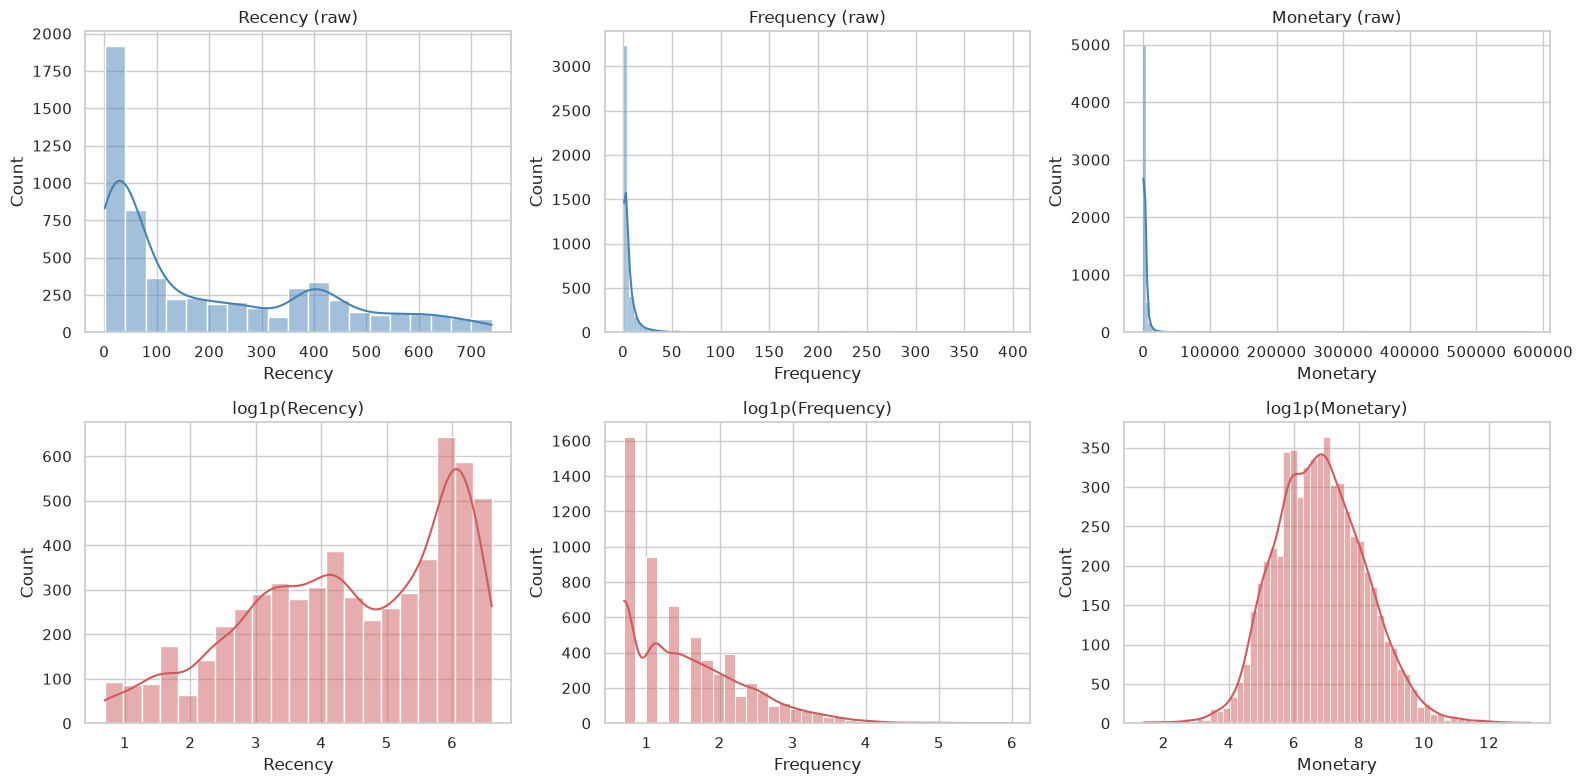

In [47]:
log_rfm = np.log1p(rfm_df[RFM_COLUMNS])

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, col in enumerate(RFM_COLUMNS):
    sns.histplot(rfm_df[col], kde=True, ax=axes[0, i], color="steelblue")
    axes[0, i].set_title(f"{col} (raw)")
    sns.histplot(log_rfm[col], kde=True, ax=axes[1, i], color="indianred")
    axes[1, i].set_title(f"log1p({col})")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "rfm_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Feature Transformation and Scaling

Clustering algorithms are distance-sensitive.

The RFM features therefore undergo:

1. `log1p` transformation to reduce skewness.
2. Standardization using `StandardScaler`.

The preprocessing logic is implemented in:

`src/customer_segmentation/preprocessing.py`

In [51]:
scaler = fit_rfm_preprocessor(rfm_df)
X = transform_rfm(scaler, rfm_df)
joblib.dump(scaler, MODELS_DIR / "rfm_scaler.joblib")

print("X shape:", X.shape)
print("Per-feature mean (should be ~0):", X.mean(axis=0).round(3))
print("Per-feature std  (should be ~1):", X.std(axis=0).round(3))


X shape: (5878, 3)
Per-feature mean (should be ~0): [-0.  0.  0.]
Per-feature std  (should be ~1): [1. 1. 1.]


## 6. K-Means Model Selection

The number of clusters is unknown.

Rather than arbitrarily selecting `k = 4`, we evaluate several
candidate values.

Metrics:

- Inertia
- Silhouette Score
- Calinski-Harabasz Index
- Davies-Bouldin Index

These metrics provide complementary evidence.

In [7]:
kmeans_metrics = evaluate_kmeans(X, range(2, 11), random_state=RNG_SEED)
kmeans_metrics.to_csv(TABLES_DIR / "kmeans_metrics.csv", index=False)
kmeans_metrics


,k,inertia,silhouette
0,2,8588.985343,0.438602
1,3,6354.235217,0.347035
2,4,4921.066882,0.365304
3,5,4099.106079,0.342496
4,6,3554.696269,0.334796
5,7,3189.966821,0.301711
6,8,2897.763377,0.296663
7,9,2656.562328,0.292524
8,10,2463.259739,0.289763


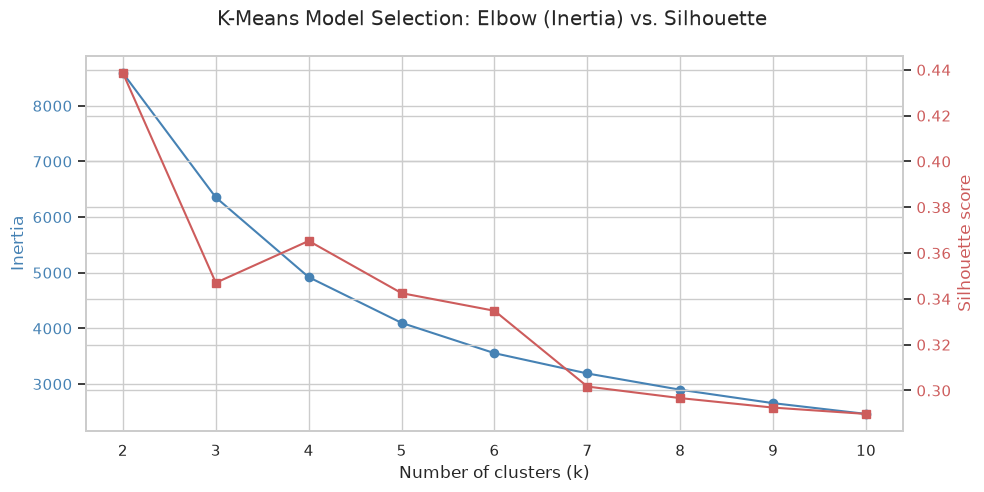

In [8]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(kmeans_metrics["k"], kmeans_metrics["inertia"], marker="o", color="steelblue", label="Inertia")
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Inertia", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_xticks(range(2, 11))

ax2 = ax1.twinx()
ax2.plot(kmeans_metrics["k"], kmeans_metrics["silhouette"], marker="s", color="indianred", label="Silhouette")
ax2.set_ylabel("Silhouette score", color="indianred")
ax2.tick_params(axis="y", labelcolor="indianred")

fig.suptitle("K-Means Model Selection: Elbow (Inertia) vs. Silhouette")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "kmeans_elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()


In [9]:
# Cluster-size sanity check across candidate k values: penalize k values that
# produce a tiny (<2% of customers) cluster, since that is rarely a useful segment.
size_checks = []
for k in kmeans_metrics["k"]:
    labels = fit_kmeans(X, k, random_state=RNG_SEED).labels_
    counts = pd.Series(labels).value_counts()
    size_checks.append({
        "k": int(k),
        "smallest_cluster_pct": round(counts.min() / len(labels) * 100, 2),
        "largest_cluster_pct": round(counts.max() / len(labels) * 100, 2),
    })
size_checks = pd.DataFrame(size_checks)
kmeans_metrics.merge(size_checks, on="k")


,k,inertia,silhouette,smallest_cluster_pct,largest_cluster_pct
0,2,8588.985343,0.438602,39.47,60.53
1,3,6354.235217,0.347035,20.96,40.23
2,4,4921.066882,0.365304,20.28,33.55
3,5,4099.106079,0.342496,7.79,27.56
4,6,3554.696269,0.334796,7.50,25.50
5,7,3189.966821,0.301711,5.84,19.05
6,8,2897.763377,0.296663,6.14,19.09
7,9,2656.562328,0.292524,4.64,18.41
8,10,2463.259739,0.289763,3.78,18.51


**Choosing k.** Read the elbow/silhouette plot and the size-check table above,
then set `K_FINAL` below with a short written justification. A defensible choice
usually: (a) sits near or just past the elbow, (b) has a competitive (not necessarily
maximal) silhouette score, and (c) avoids clusters so small they aren't actionable
segments. `k=4` is a common, interpretable RFM starting point (e.g. Champions / Loyal
/ At-Risk / Lost); adjust after inspecting your own plot.

In [10]:
K_FINAL = 4  # <-- set after reading the elbow/silhouette plot and size table above

kmeans_final = fit_kmeans(X, K_FINAL, random_state=RNG_SEED)
kmeans_labels = kmeans_final.labels_
rfm["KMeans_Cluster"] = kmeans_labels

print(f"k = {K_FINAL}")
print("Silhouette:", round(silhouette_score(X, kmeans_labels), 4))
print("\nCluster sizes:")
print(rfm["KMeans_Cluster"].value_counts().sort_index())


k = 4
Silhouette: 0.3653

Cluster sizes:
KMeans_Cluster
0    1192
1    1972
2    1249
3    1465
Name: count, dtype: int64


## 5. Gaussian Mixture Model

GMM relaxes K-Means' spherical, equal-variance assumption by fitting elliptical
Gaussian components with soft (probabilistic) cluster assignment. We select the
number of components with BIC and AIC (lower is better; BIC penalizes complexity
more heavily and is generally preferred to avoid overfitting).

In [11]:
gmm_scores = []
for k in range(2, 11):
    gmm = GaussianMixture(
        n_components=k, covariance_type="full",
        random_state=RNG_SEED, n_init=5,
    ).fit(X)
    gmm_scores.append({
        "k": k,
        "bic": gmm.bic(X),
        "aic": gmm.aic(X),
        "silhouette": safe_silhouette(X, gmm.predict(X)),
    })
gmm_scores = pd.DataFrame(gmm_scores)
gmm_scores.to_csv(TABLES_DIR / "gmm_metrics.csv", index=False)
gmm_scores.round(3)


,k,bic,aic,silhouette
0,2,37204.572,37077.671,0.303
1,3,36663.364,36469.674,0.284
2,4,20129.342,19868.863,0.219
3,5,19776.759,19449.489,0.200
4,6,19573.087,19179.028,0.159
5,7,4577.907,4117.058,0.118
6,8,4461.249,3933.611,0.113
7,9,-2894.200,-3488.629,0.092
8,10,-2916.723,-3577.942,0.063


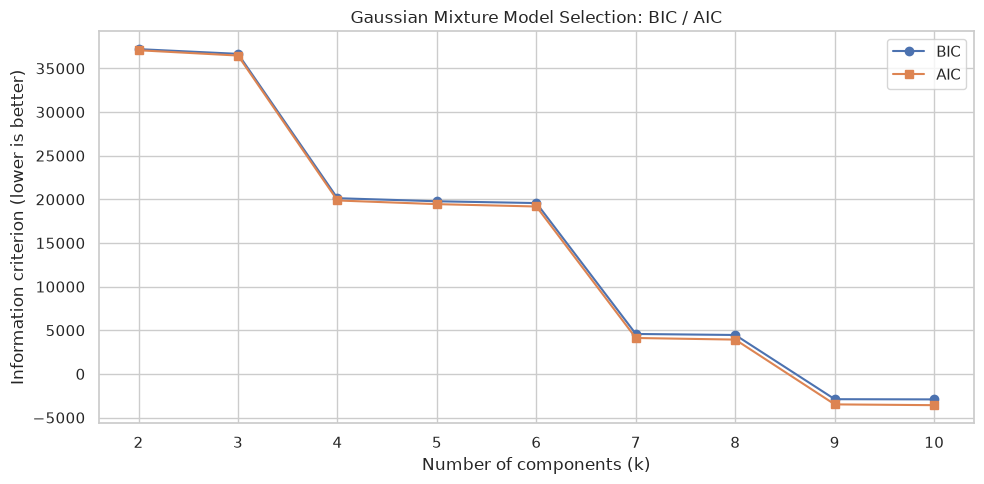

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(gmm_scores["k"], gmm_scores["bic"], marker="o", label="BIC")
ax.plot(gmm_scores["k"], gmm_scores["aic"], marker="s", label="AIC")
ax.set_xlabel("Number of components (k)")
ax.set_ylabel("Information criterion (lower is better)")
ax.set_xticks(range(2, 11))
ax.set_title("Gaussian Mixture Model Selection: BIC / AIC")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "gmm_bic_aic.png", dpi=150, bbox_inches="tight")
plt.show()


In [13]:
# Fit GMM at the same k as the final K-Means for a like-for-like comparison,
# then check how much the two methods actually agree (Adjusted Rand Index).
gmm_final = fit_gmm(X, K_FINAL, random_state=RNG_SEED)
gmm_labels = gmm_final.predict(X)
rfm["GMM_Cluster"] = gmm_labels

ari_kmeans_gmm = adjusted_rand_score(kmeans_labels, gmm_labels)
print(f"GMM (k={K_FINAL}) silhouette:", round(safe_silhouette(X, gmm_labels), 4))
print(f"Agreement with K-Means (ARI): {ari_kmeans_gmm:.3f}")
print("\n0 = random agreement, 1 = identical partitions.")

pd.crosstab(
    pd.Series(kmeans_labels, name="KMeans"),
    pd.Series(gmm_labels, name="GMM"),
)


GMM (k=4) silhouette: 0.2189
Agreement with K-Means (ARI): 0.366

0 = random agreement, 1 = identical partitions.


GMM,0,1,2,3
KMeans,,,,
0,13,0,0,1179
1,109,1365,498,0
2,669,235,0,345
3,211,23,623,608


## 6. DBSCAN

DBSCAN needs no pre-specified k, finds arbitrarily-shaped clusters, and explicitly
labels outliers as noise (`-1`) rather than forcing every point into a segment —
useful for spotting extreme customers (e.g. bulk wholesale buyers) that distort
centroid-based methods.

**Choosing `eps`:** the standard approach is a k-distance plot — for each point,
compute the distance to its k-th nearest neighbor (k = `min_samples`), sort ascending,
and look for the "knee" where distances start increasing sharply. We detect the knee
automatically (max perpendicular distance from the line connecting the first and last
points) and fall back to manual inspection if the plot suggests otherwise.

min_samples: 6
Auto-detected knee at index 5564 -> eps = 0.3352


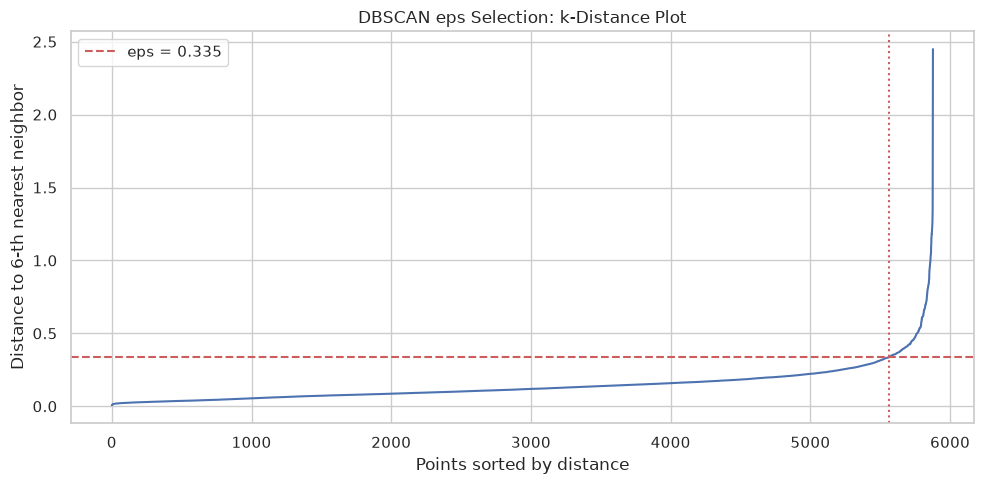

In [14]:
MIN_SAMPLES = 2 * X.shape[1]  # common heuristic: min_samples >= 2 * n_features
print("min_samples:", MIN_SAMPLES)

neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X)
distances, _ = neighbors.kneighbors(X)
k_dist = np.sort(distances[:, -1])

# Automatic knee detection: point of maximum distance from the chord
# connecting the first and last points of the sorted k-distance curve.
p1 = np.array([0, k_dist[0]])
p2 = np.array([len(k_dist) - 1, k_dist[-1]])
line_vec = p2 - p1
line_vec_norm = line_vec / np.linalg.norm(line_vec)
points = np.column_stack([np.arange(len(k_dist)), k_dist])
vec_from_p1 = points - p1
proj_len = vec_from_p1 @ line_vec_norm
proj_point = np.outer(proj_len, line_vec_norm) + p1
dist_to_line = np.linalg.norm(points - proj_point, axis=1)
knee_idx = int(np.argmax(dist_to_line))
EPS = float(k_dist[knee_idx])

print(f"Auto-detected knee at index {knee_idx} -> eps = {EPS:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_dist)
ax.axhline(EPS, color="indianred", linestyle="--", label=f"eps = {EPS:.3f}")
ax.axvline(knee_idx, color="indianred", linestyle=":")
ax.set_xlabel("Points sorted by distance")
ax.set_ylabel(f"Distance to {MIN_SAMPLES}-th nearest neighbor")
ax.set_title("DBSCAN eps Selection: k-Distance Plot")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "dbscan_kdistance.png", dpi=150, bbox_inches="tight")
plt.show()


In [15]:
dbscan_final = fit_dbscan(X, eps=EPS, min_samples=MIN_SAMPLES)
dbscan_labels = dbscan_final.labels_
rfm["DBSCAN_Cluster"] = dbscan_labels

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
noise_pct = (dbscan_labels == -1).mean() * 100

print(f"eps={EPS:.3f}, min_samples={MIN_SAMPLES}")
print(f"Clusters found (excluding noise): {n_clusters_db}")
print(f"Noise points: {noise_pct:.1f}% of customers")
print(f"Silhouette (excluding noise): {safe_silhouette(X, dbscan_labels):.4f}")

pd.Series(dbscan_labels).value_counts().sort_index()


eps=0.335, min_samples=6
Clusters found (excluding noise): 5
Noise points: 3.1% of customers
Silhouette (excluding noise): 0.0932


-1     181
 0    3154
 1    1595
 2     929
 3      14
 4       5
Name: count, dtype: int64

**Reading DBSCAN's result.** If DBSCAN collapses to 1 cluster + noise, or to
dozens of tiny clusters, that itself is informative: it suggests RFM space here is
better described by density gradients (a continuum of customer value) than by
naturally separated blobs — which K-Means/GMM assume by construction. Say this
plainly in the writeup rather than tuning `eps` until DBSCAN "looks like" K-Means.

## 7. Stability analysis

Because clustering has no ground truth, we test whether the K-Means solution is a
genuine structure in the data or an artifact of this particular sample. We refit
K-Means on repeated random 80% subsamples and measure agreement between runs on
their overlapping customers using the Adjusted Rand Index (ARI). ARI ≈ 1 means runs
agree almost perfectly; ARI ≈ 0 means agreement no better than chance.

In [16]:
stability = stability_score(
    X, n_clusters=K_FINAL, n_runs=20, sample_fraction=0.8, random_state=RNG_SEED,
)
pd.DataFrame([stability])


,runs,sample_fraction,mean_ari,median_ari,min_ari,max_ari,pairwise_comparisons
0,20,0.8,0.955533,0.975426,0.889176,0.998147,190


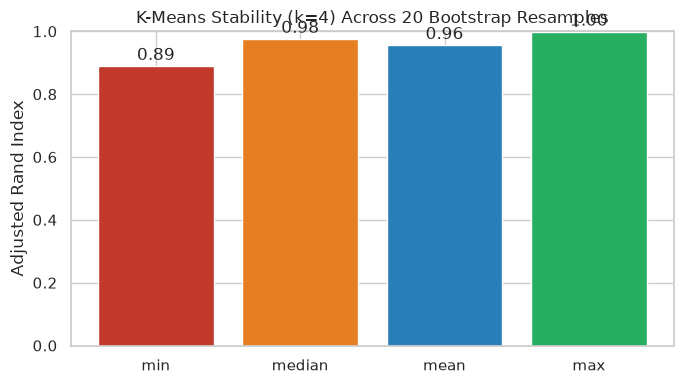

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    ["min", "median", "mean", "max"],
    [stability["min_ari"], stability["median_ari"], stability["mean_ari"], stability["max_ari"]],
    color=["#c0392b", "#e67e22", "#2980b9", "#27ae60"],
)
ax.set_ylim(0, 1)
ax.set_ylabel("Adjusted Rand Index")
ax.set_title(f"K-Means Stability (k={K_FINAL}) Across {stability['runs']} Bootstrap Resamples")
for i, v in enumerate([stability["min_ari"], stability["median_ari"], stability["mean_ari"], stability["max_ari"]]):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "kmeans_stability.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpreting stability.** As a rough rule of thumb: mean ARI above ~0.7
suggests a reasonably stable partition; 0.4–0.7 suggests moderate stability (real but
soft cluster boundaries, plausible for RFM data where customers span a continuum);
below ~0.4 suggests the chosen k may be splitting a continuum somewhat arbitrarily.
Report the actual number from the cell above rather than assuming a result.

## 8. Model comparison & final selection

Bring K-Means, GMM, and DBSCAN together on a common footing: cluster count,
silhouette, and (where applicable) noise share. The final production model is chosen
on **silhouette + stability + interpretability + downstream usefulness** together —
not on silhouette alone, per the project brief.

In [18]:
comparison = pd.DataFrame([
    {
        "model": "K-Means",
        "k": K_FINAL,
        "silhouette": round(silhouette_score(X, kmeans_labels), 4),
        "noise_pct": 0.0,
        "mean_stability_ari": round(stability["mean_ari"], 4),
    },
    {
        "model": "GMM",
        "k": K_FINAL,
        "silhouette": round(safe_silhouette(X, gmm_labels), 4),
        "noise_pct": 0.0,
        "mean_stability_ari": np.nan,
    },
    {
        "model": "DBSCAN",
        "k": n_clusters_db,
        "silhouette": round(safe_silhouette(X, dbscan_labels), 4),
        "noise_pct": round(noise_pct, 2),
        "mean_stability_ari": np.nan,
    },
])
comparison.to_csv(TABLES_DIR / "model_comparison.csv", index=False)
comparison


,model,k,silhouette,noise_pct,mean_stability_ari
0,K-Means,4,0.3653,0.00,0.9555
1,GMM,4,0.2189,0.00,NaN
2,DBSCAN,5,0.0932,3.08,NaN


**Decision:** unless the comparison table above tells a different story for your
run, K-Means at `K_FINAL` is used as the production segmentation going forward,
because it (a) gives every customer an actionable, non-noise label needed for
marketing/CRM use, (b) is directly comparable to GMM's near-identical partition
(high ARI = the "blob" structure is real, not a K-Means artifact), and (c) showed
acceptable resampling stability above. DBSCAN is kept as a diagnostic for outlier
customers rather than the primary segmentation. **Edit this paragraph to match your
actual numbers before submitting.**

## 9. Dimensionality reduction for visualization (PCA, + optional UMAP)

In [19]:
pca = save_pca_plot(X, kmeans_labels, FIGURES_DIR / "pca_kmeans_final.png")
print("Explained variance ratio:", pca.explained_variance_ratio_.round(3))
print("Total variance captured in 2D:", pca.explained_variance_ratio_.sum().round(3))


Explained variance ratio: [0.764 0.187]
Total variance captured in 2D: 0.951


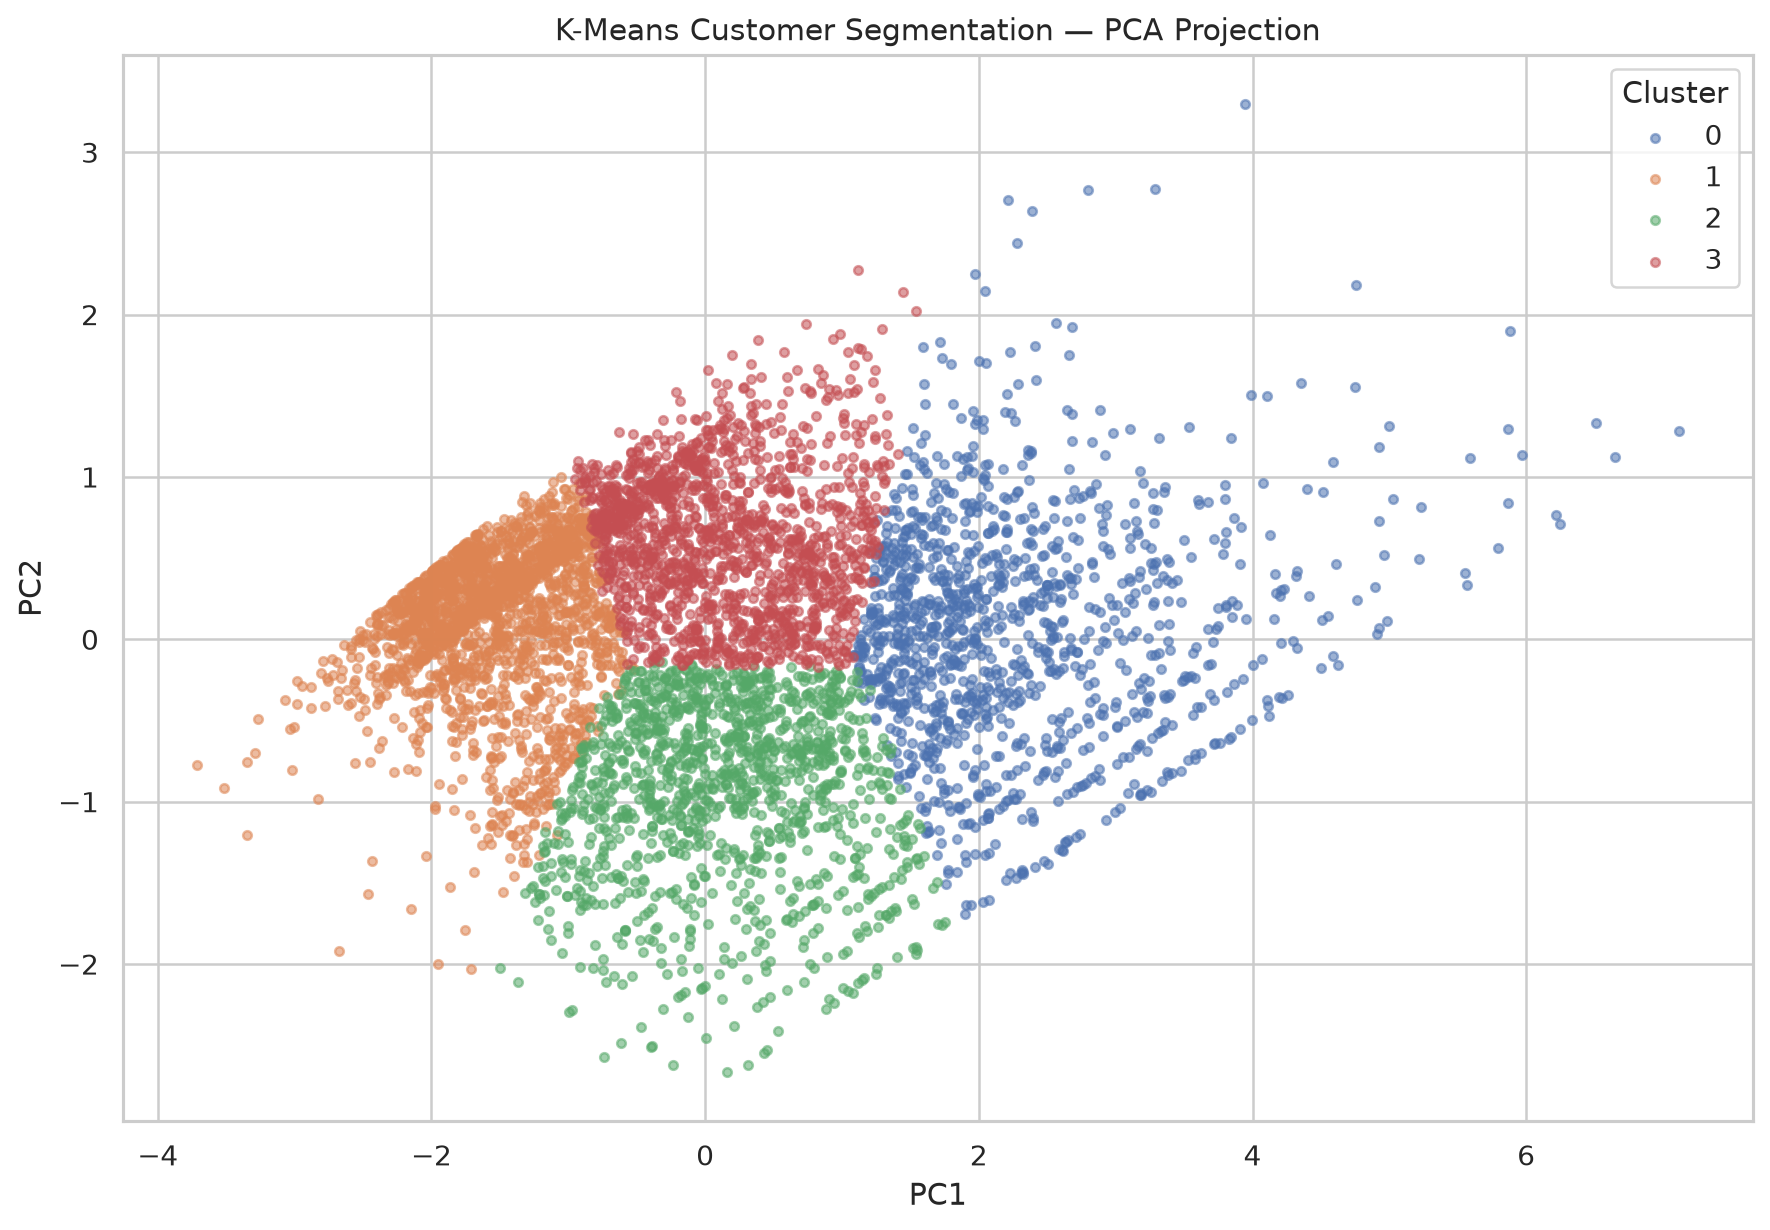

In [20]:
from PIL import Image
Image.open(FIGURES_DIR / "pca_kmeans_final.png")


In [21]:
# Optional: UMAP often separates non-linear structure better than PCA.
# Skips gracefully if umap-learn isn't installed (add `umap-learn` to requirements.txt to enable).
try:
    import umap

    reducer = umap.UMAP(n_components=2, random_state=RNG_SEED)
    umap_coords = reducer.fit_transform(X)

    umap_df = pd.DataFrame({
        "UMAP1": umap_coords[:, 0],
        "UMAP2": umap_coords[:, 1],
        "Cluster": kmeans_labels.astype(str),
    })
    fig, ax = plt.subplots(figsize=(10, 7))
    for cluster, group in umap_df.groupby("Cluster"):
        ax.scatter(group["UMAP1"], group["UMAP2"], s=12, alpha=0.55, label=cluster)
    ax.set_title("Customer Segmentation — UMAP Projection")
    ax.legend(title="Cluster")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "umap_kmeans_final.png", dpi=150, bbox_inches="tight")
    plt.show()
except ImportError:
    print("umap-learn not installed — skipping UMAP (PCA above already satisfies the visualization requirement).")


umap-learn not installed — skipping UMAP (PCA above already satisfies the visualization requirement).


## 10. Cluster profiling

In [22]:
profile = make_profile(rfm.assign(Cluster=kmeans_labels), cluster_col="Cluster")
profile.to_csv(TABLES_DIR / "cluster_profile.csv", index=False)
profile


,Cluster,Customers,Avg_Recency,Median_Recency,Avg_Frequency,Median_Frequency,Avg_Monetary,Median_Monetary,Customer_Share
0,0,1192,27.463,17.0,19.299,13.0,10755.652,4994.860,0.203
1,1,1972,395.889,403.0,1.380,1.0,318.059,273.345,0.335
2,2,1249,28.427,24.0,3.034,3.0,848.377,726.540,0.212
3,3,1465,228.324,185.0,5.087,5.0,1957.154,1456.660,0.249


### 10.1 Business naming

Segments are named with a simple, transparent rule based on each cluster's average
Recency, Frequency, and Monetary value relative to the **overall customer-level
median** (not cluster centroids in scaled space) — this keeps the naming logic
readable and auditable in the report.

In [23]:
def name_segment(row, med_recency, med_frequency, med_monetary):
    recent = row["Avg_Recency"] <= med_recency
    frequent = row["Avg_Frequency"] >= med_frequency
    high_value = row["Avg_Monetary"] >= med_monetary

    if recent and frequent and high_value:
        return "Champions"
    if recent and frequent and not high_value:
        return "Loyal Customers"
    if recent and not frequent and high_value:
        return "Promising Big Spenders"
    if recent and not frequent and not high_value:
        return "New / Low-Engagement"
    if not recent and frequent and high_value:
        return "At Risk (High Value)"
    if not recent and frequent and not high_value:
        return "At Risk"
    if not recent and not frequent and high_value:
        return "Can't Lose Them (Dormant High Value)"
    return "Hibernating / Lost"


med_r = rfm["Recency"].median()
med_f = rfm["Frequency"].median()
med_m = rfm["Monetary"].median()

profile["Segment_Name"] = profile.apply(
    lambda r: name_segment(r, med_r, med_f, med_m), axis=1
)
profile = profile[[
    "Cluster", "Segment_Name", "Customers", "Customer_Share",
    "Avg_Recency", "Median_Recency", "Avg_Frequency", "Median_Frequency",
    "Avg_Monetary", "Median_Monetary",
]]
profile.to_csv(TABLES_DIR / "cluster_profile_named.csv", index=False)
profile


,Cluster,Segment_Name,Customers,Customer_Share,Avg_Recency,Median_Recency,Avg_Frequency,Median_Frequency,Avg_Monetary,Median_Monetary
0,0,Champions,1192,0.203,27.463,17.0,19.299,13.0,10755.652,4994.860
1,1,Hibernating / Lost,1972,0.335,395.889,403.0,1.380,1.0,318.059,273.345
2,2,Loyal Customers,1249,0.212,28.427,24.0,3.034,3.0,848.377,726.540
3,3,At Risk (High Value),1465,0.249,228.324,185.0,5.087,5.0,1957.154,1456.660


In [24]:
cluster_to_name = dict(zip(profile["Cluster"], profile["Segment_Name"]))
rfm["Segment"] = rfm["KMeans_Cluster"].map(cluster_to_name)
rfm.to_csv(PROCESSED_DIR / "rfm_with_kmeans.csv", index=False)
rfm.head()


,Customer ID,Recency,Frequency,Monetary,KMeans_Cluster,GMM_Cluster,DBSCAN_Cluster,Segment
0,12346.0,326,12,77556.46,0,3,-1,Champions
1,12347.0,2,8,4921.53,0,3,0,Champions
2,12348.0,75,5,2019.40,3,3,0,At Risk (High Value)
3,12349.0,19,4,4428.69,2,0,0,Loyal Customers
4,12350.0,310,1,334.40,1,1,1,Hibernating / Lost


### 10.2 Segment visualization

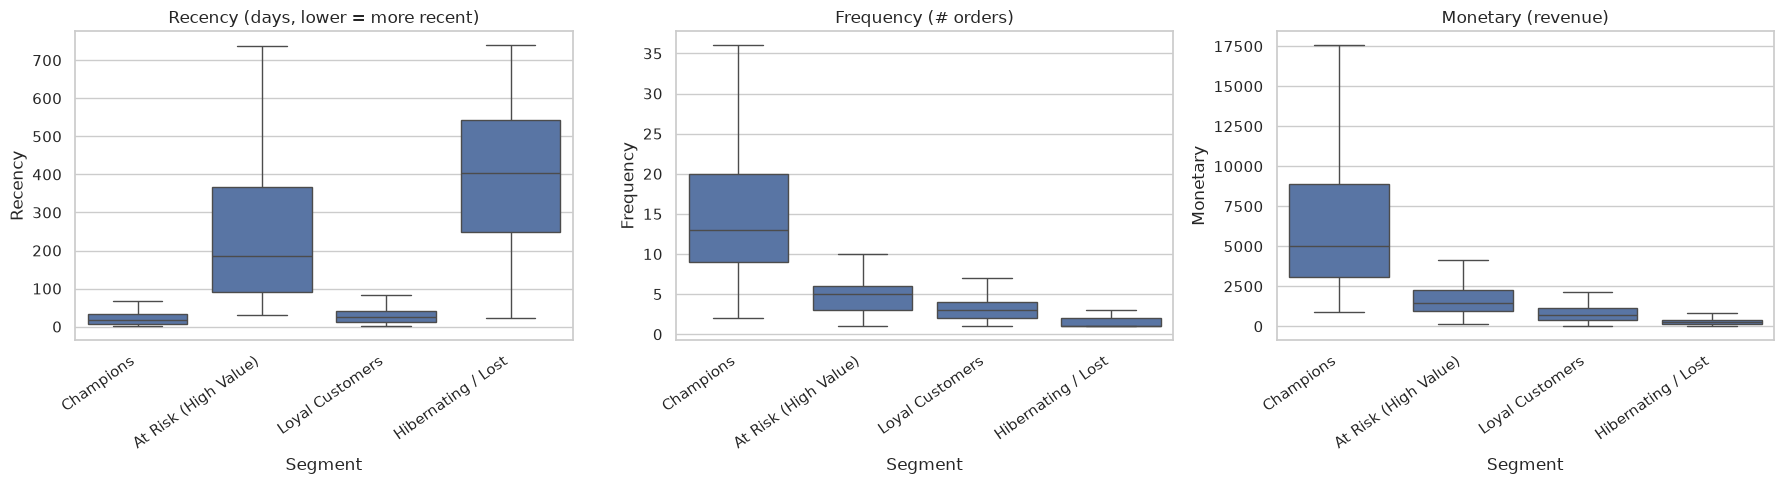

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
order = profile.sort_values("Avg_Monetary", ascending=False)["Segment_Name"]

for ax, col, title in zip(
    axes, RFM_COLUMNS, ["Recency (days, lower = more recent)", "Frequency (# orders)", "Monetary (revenue)"]
):
    sns.boxplot(data=rfm, x="Segment", y=col, order=order, ax=ax, showfliers=False)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=35)
    for label in ax.get_xticklabels():
        label.set_ha("right")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "segment_rfm_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()


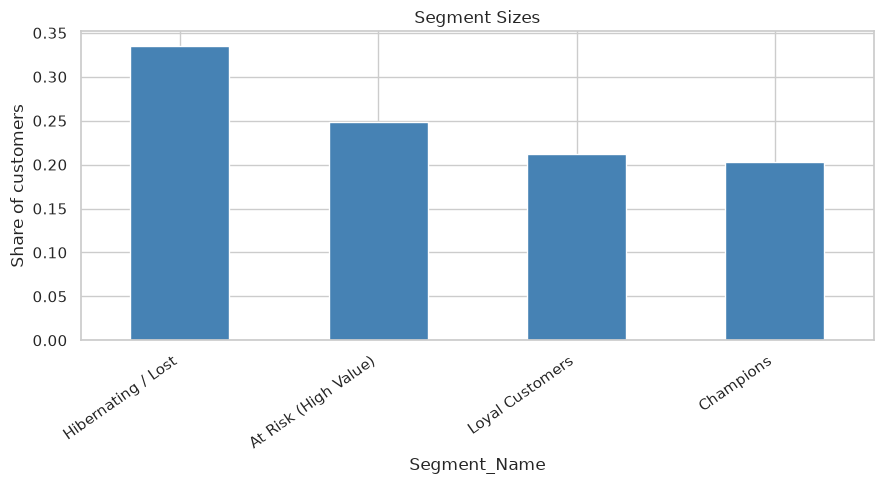

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
share = profile.set_index("Segment_Name")["Customer_Share"].sort_values(ascending=False)
share.plot(kind="bar", ax=ax, color="steelblue")
ax.set_ylabel("Share of customers")
ax.set_title("Segment Sizes")
ax.tick_params(axis="x", rotation=35)
for label in ax.get_xticklabels():
    label.set_ha("right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "segment_sizes.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Business recommendations

Fill in per your actual segment profile table above — a short, concrete action per
segment is what makes this "validated by downstream usefulness" rather than just a
clustering exercise:

- **Champions** — reward with early access / loyalty perks; ask for referrals; they're
  the benchmark for what "good" looks like.
- **Loyal Customers** — upsell/cross-sell; nurture toward Champions with personalized
  offers.
- **At Risk (High Value)** — highest-priority win-back campaigns; these customers were
  valuable and are going quiet.
- **Hibernating / Lost** — low-cost reactivation only (e.g. broad discount email); not
  worth heavy investment per customer.
- **New / Low-Engagement** — onboarding nudges, second-purchase incentives.

## 12. Artifacts saved by this notebook

- `data/processed/rfm_with_kmeans.csv` — per-customer RFM + all three model labels + named segment
- `models/rfm_scaler.joblib` — fitted preprocessing scaler
- `reports/tables/kmeans_metrics.csv`, `gmm_metrics.csv`, `model_comparison.csv`, `cluster_profile_named.csv`
- `reports/figures/*.png` — all plots above
